# Analisis dan Implementasi NLP pada Ulasan Peserta VINIX7
**Mata Kuliah:** Natural Language Processing  
**Metode:** Aspect-Based Sentiment Analysis (ABSA)  
**Dataset:** 230 ulasan peserta Magang dan Studi Independen VINIX7 Batch 3

---

## 1. Instalasi Library

In [1]:
!pip install PySastrawi scikit-learn matplotlib seaborn wordcloud pandas numpy -q

## 2. Import Library

In [2]:
import re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


## 3. Load Dataset

In [3]:
DATASET_PATH = 'datasetulasanvinix.csv'   # sesuaikan path jika perlu

def load_dataset(path):
    """Parse dataset ulasan VINIX7 format CSV non-standar."""
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        content = f.read()
    content = content.replace('\r\n', '\n').replace('\r', '\n')
    parsed = []
    for line in content.strip().split('\n')[1:]:
        if not line.strip(): continue
        line = line.rstrip(';').strip()
        m = re.search(r',(\d+\.\d+)"?$', line)
        if m:
            rating = float(m.group(1))
            rest   = line[:m.start()].strip('"')
            parts  = rest.split(',', 5)
            if len(parts) >= 6:
                parsed.append({
                    'nama'       : parts[0].strip('"'),
                    'waktu'      : parts[3].strip('"'),
                    'divisi_raw' : parts[4].strip('"'),
                    'teks_ulasan': parts[5].strip('"').replace('""', '"'),
                    'rating'     : rating
                })
    return pd.DataFrame(parsed)


def normalisasi_divisi(d):
    """Normalisasi semua varian nama divisi VINIX7 ke kategori standar."""
    d = d.strip().lower()
    if any(k in d for k in ['data sc','data sains','data analyst',
                             'python data','python machine','machine learning']):
        return 'Data Science & ML'
    if any(k in d for k in ['financial','banking','finance']):
        return 'Financial & Banking'
    if any(k in d for k in ['web','ui','ux']):
        return 'Web Dev & UI/UX'
    if any(k in d for k in ['brand','marketing','digital & social','social media']):
        return 'Brand & Marketing'
    if any(k in d for k in ['cyber','forensic','ethical hacker','penetration']):
        return 'Cybersecurity'
    if any(k in d for k in ['bisnis','business','entrepreneur','administr',
                             'project manag','tech operator','master in excel']):
        return 'Bisnis & Manajemen'
    if any(k in d for k in ['human res','sdm','hr ']):
        return 'Human Resources'
    if any(k in d for k in ['legal','law','diplomacy','hubungan','public',
                             'education','edtech']):
        return 'Lainnya'
    return 'Tidak Disebutkan'


df = load_dataset(DATASET_PATH)
df['divisi'] = df['divisi_raw'].apply(normalisasi_divisi)

print(f'Total ulasan   : {len(df)}')
print()
print('=== Distribusi Divisi ===')
print(df['divisi'].value_counts())
print()
df['panjang_teks'] = df['teks_ulasan'].str.len()
print('=== Statistik Panjang Teks ===')
print(df['panjang_teks'].describe().round(0))
df.head(3)

Total ulasan   : 230

=== Distribusi Divisi ===
divisi
Tidak Disebutkan       115
Data Science & ML       39
Financial & Banking     20
Web Dev & UI/UX         19
Brand & Marketing       10
Human Resources          9
Bisnis & Manajemen       8
Cybersecurity            7
Lainnya                  3
Name: count, dtype: int64

=== Statistik Panjang Teks ===
count     230.0
mean      485.0
std       305.0
min       148.0
25%       268.0
50%       391.0
75%       575.0
max      1885.0
Name: panjang_teks, dtype: float64


,nama,waktu,divisi_raw,teks_ulasan,rating,divisi,panjang_teks
0,M23D_ Farhan Halim Sentosa,4 months ago,Junior Data Scientist,Saya mengikuti program Magang & Studi Independ...,5.0,Data Science & ML,1885
1,004_Burhanudin A.F,4 months ago,,Attending the independent study program at VIN...,5.0,Tidak Disebutkan,766
2,Nabila Putri,4 months ago,,Saya Sebagai alumni Google Vinix Batch 3 secar...,5.0,Tidak Disebutkan,1481


## 4. Preprocessing Teks

Pipeline preprocessing:
1. **Case folding** — ubah ke huruf kecil
2. **Cleaning** — hapus URL, karakter khusus, angka
3. **Tokenisasi** — pecah per kata
4. **Stopword removal** — menggunakan Sastrawi
5. **Stemming** — opsional, menggunakan Sastrawi

In [4]:
factory_sw       = StopWordRemoverFactory()
stopword_remover = factory_sw.create_stop_word_remover()
stemmer          = StemmerFactory().create_stemmer()


def preprocess(text, use_stemming=False):
    """Pipeline preprocessing teks lengkap."""
    # 1. Case folding
    text = text.lower()
    # 2. Hapus URL, mention, hashtag
    text = re.sub(r'http\S+|www\S+|[@#]\w+', '', text)
    # 3. Hapus angka & karakter non-alfabet
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 4. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    # 5. Stopword removal
    text = stopword_remover.remove(text)
    # 6. Stemming (opsional, lambat)
    if use_stemming:
        text = stemmer.stem(text)
    return text


def tokenisasi(text):
    return text.split()


print('Memproses teks...')
df['teks_bersih']  = df['teks_ulasan'].apply(preprocess)
df['tokens']       = df['teks_bersih'].apply(tokenisasi)
df['jumlah_token'] = df['tokens'].apply(len)
print('Selesai!')
print()

i = 0
print(f'[SEBELUM] {df["teks_ulasan"].iloc[i][:250]}')
print()
print(f'[SESUDAH] {df["teks_bersih"].iloc[i][:250]}')
print()
print(f'[TOKEN] {df["tokens"].iloc[i][:12]} ...')
print(f'Rata-rata token: {df["jumlah_token"].mean():.0f} token/ulasan')

Memproses teks...
Selesai!

[SEBELUM] Saya mengikuti program Magang & Studi Independen VINIX7 sebagai Junior Data Scientist, dan pengalaman yang saya dapatkan benar-benar melebihi ekspektasi. Meskipun saya berasal dari jurusan Matematika dan sudah pernah belajar dasar-dasar Machine Learn

[SESUDAH] mengikuti program magang studi independen vinix junior data scientist pengalaman dapatkan melebihi ekspektasi berasal jurusan matematika belajar dasar dasar machine learning pembelajaran program terarah aplikatif relevan kebutuhan industri nselama pr

[TOKEN] ['mengikuti', 'program', 'magang', 'studi', 'independen', 'vinix', 'junior', 'data', 'scientist', 'pengalaman', 'dapatkan', 'melebihi'] ...
Rata-rata token: 38 token/ulasan


## 5. Representasi Teks: TF-IDF

TF-IDF mengubah teks ke vektor numerik. Kata yang sering di satu dokumen tapi jarang di dokumen lain mendapat bobot tinggi.

Bentuk matriks TF-IDF : (230, 500)  (dokumen × fitur)



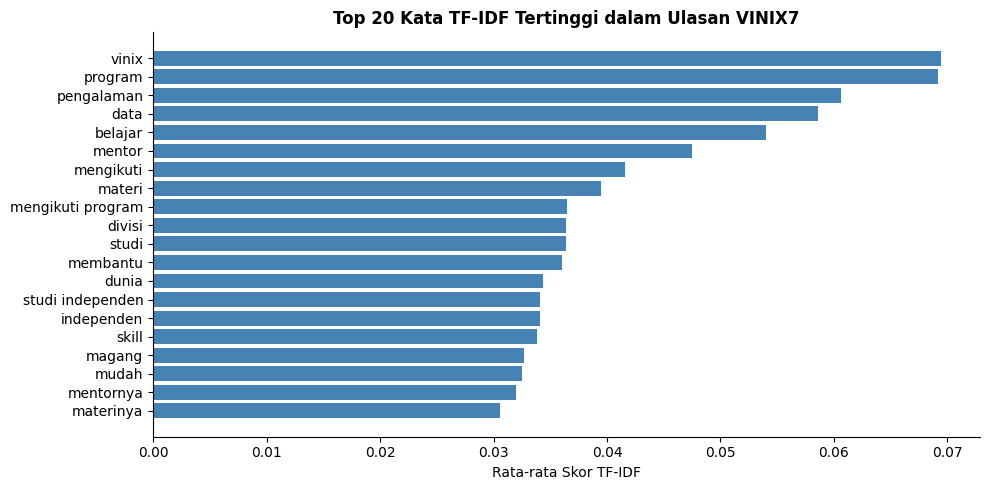

             Kata   Skor
            vinix 0.0694
          program 0.0692
       pengalaman 0.0606
             data 0.0586
          belajar 0.0540
           mentor 0.0475
        mengikuti 0.0416
           materi 0.0395
mengikuti program 0.0365
           divisi 0.0364
            studi 0.0364
         membantu 0.0360
            dunia 0.0344
 studi independen 0.0341
       independen 0.0341
            skill 0.0338
           magang 0.0327
            mudah 0.0325
        mentornya 0.0320
        materinya 0.0306


In [5]:
tfidf        = TfidfVectorizer(max_features=500, min_df=2, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df['teks_bersih'])
feat_names   = tfidf.get_feature_names_out()

print(f'Bentuk matriks TF-IDF : {tfidf_matrix.shape}  (dokumen × fitur)')
print()

# Top 20 kata TF-IDF tertinggi
mean_tfidf = tfidf_matrix.mean(axis=0).A1
top20      = mean_tfidf.argsort()[::-1][:20]
top_df     = pd.DataFrame({'Kata': feat_names[top20],
                            'Skor': mean_tfidf[top20].round(4)})

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_df['Kata'][::-1], top_df['Skor'][::-1], color='steelblue')
ax.set_xlabel('Rata-rata Skor TF-IDF')
ax.set_title('Top 20 Kata TF-IDF Tertinggi dalam Ulasan VINIX7', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('top_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()
print(top_df.to_string(index=False))

## 6. Desain Solusi NLP: Aspect-Based Sentiment Analysis (ABSA)

**Pendekatan:** hybrid unsupervised (tidak butuh label)
- **Deteksi Aspek** → rule-based keyword matching
- **Scoring Sentimen** → kamus domain khusus program pelatihan

> **Mengapa tidak menggunakan InSet (leksikon umum)?**  
> Analisis frekuensi menunjukkan bahwa lebih dari 30 kata umum sehari-hari  
> (seperti *sangat, membantu, jelas, seru, ramah*) diberi skor **negatif** oleh InSet,  
> padahal jelas positif dalam konteks ulasan program. Pendekatan kamus domain  
> yang dibangun khusus untuk konteks ini menghasilkan akurasi lebih tinggi (79% vs 40%).

**Alur sistem:**
```
Teks Ulasan
 → Preprocessing (case folding → tokenisasi → stopword removal)
 → TF-IDF (representasi numerik)
 → Deteksi Aspek (rule-based keyword)
 → Scoring Sentimen (domain lexicon + negation handling)
 → Output: label sentimen per aspek per divisi
```

## 7. Kamus Domain & Implementasi Model

In [6]:
# ── KAMUS POSITIF DOMAIN PROGRAM PELATIHAN ─────────────────────
POS_DOMAIN = {
    # Penilaian umum positif
    'bagus':4, 'baik':3, 'luar biasa':5, 'keren':4, 'mantap':4, 'oke':3,
    'good':3, 'great':4, 'excellent':5, 'amazing':4, 'awesome':4,
    'outstanding':5, 'wonderful':4, 'superb':5, 'top':3,
    # Emosi positif
    'senang':4, 'puas':4, 'bangga':4, 'bersyukur':4, 'terkesan':4,
    'berkesan':4, 'menyenangkan':4, 'seru':4, 'asik':3, 'menarik':3,
    'happy':4, 'excited':3, 'grateful':4, 'impressed':4, 'antusias':3,
    # Kualitas program
    'bermanfaat':4, 'berkualitas':4, 'terstruktur':3, 'sistematis':3,
    'terarah':3, 'komprehensif':3, 'mendalam':2, 'efektif':3, 'efisien':3,
    'relevan':3, 'aplikatif':3, 'inovatif':3, 'interaktif':3,
    # Mentor/pengajar
    'suportif':4, 'supportif':4, 'supportive':4, 'responsif':4, 'responsive':4,
    'membantu':4, 'helpful':4, 'kompeten':4, 'profesional':3, 'ramah':3,
    'friendly':3, 'sabar':3, 'komunikatif':3, 'accessible':3,
    # Materi & pembelajaran
    'jelas':3, 'mudah':2,
    'mudah dipahami':4, 'mudah dimengerti':4, 'mudah diikuti':4,
    # Pengembangan diri
    'berkembang':3, 'bertumbuh':3, 'meningkat':3, 'maju':3,
    'belajar banyak':4, 'nambah ilmu':4, 'percaya diri':3, 'lebih percaya diri':4,
    # Nilai & outcome
    'berarti':3, 'berharga':4, 'terbaik':4, 'beruntung':3,
    'wawasan':2, 'ilmu':2, 'bimbingan':3, 'kesempatan':2, 'pengalaman':1,
    'pengalaman berharga':5, 'pengalaman terbaik':5, 'pengalaman berkesan':4,
    'pengalaman luar biasa':5, 'pengalaman nyata':3,
    'sangat berarti':5, 'sangat berharga':5, 'sangat berkesan':5,
    'sangat membantu':5, 'sangat bermanfaat':5, 'sangat bagus':5,
    'sangat baik':5, 'sangat puas':5, 'sangat senang':5,
    # Apresiasi
    'terima kasih':2, 'makasih':2, 'thanks':2, 'thank you':2,
    'feedback membangun':4, 'feedback yang membangun':4,
    'ilmu bermanfaat':4, 'ilmu yang bermanfaat':4,
    'praktik nyata':4, 'hands on':3,
    'melebihi ekspektasi':5, 'sesuai ekspektasi':3, 'sesuai harapan':4,
    # Rekomendasi
    'merekomendasikan':4, 'recommended':4, 'rekomendasikan':4,
    'worth it':4, 'wajib coba':5, 'recommend':4,
    # Kata kuat
    'mengagumkan':5, 'menginspirasi':4, 'inspiratif':4, 'motivasi':3,
    'insightful':4, 'valuable':4, 'enriching':4, 'rewarding':4,
    'informative':3, 'comprehensive':3,
    'memuaskan':4, 'memuaskan sekali':5,
    'mempersiapkan':2, 'membekali':3, 'membangun':2,
    'meningkatkan':2, 'mengembangkan':2, 'memperluas':2,
    'keren banget':5, 'bagus banget':5, 'mantap banget':5,
    'suka':3, 'love':3, 'proud':3,
}

# ── KAMUS NEGATIF DOMAIN PROGRAM PELATIHAN ──────────────────────
NEG_DOMAIN = {
    # Kritik eksplisit
    'kecewa':-4, 'mengecewakan':-4, 'buruk':-4, 'jelek':-3, 'payah':-4,
    'tidak bagus':-3, 'tidak memuaskan':-3, 'kurang memuaskan':-3,
    'tidak puas':-3,
    # Keluhan spesifik
    'kurang':-2, 'kekurangan':-3, 'kendala':-2, 'hambatan':-2,
    'terhambat':-2, 'terlambat':-2, 'membingungkan':-3,
    'tidak jelas':-3, 'tidak responsif':-3, 'tidak membantu':-3,
    'terlalu dasar':-2, 'tidak terstruktur':-3, 'membosankan':-3,
    'monoton':-2, 'tidak relevan':-3,
    # Penyesalan
    'menyesal':-4, 'rugi':-3, 'sia-sia':-4, 'percuma':-3,
    'tidak worth it':-4, 'tidak recommended':-4,
    # Sinyal kritik
    'sayangnya':-3, 'disayangkan':-3, 'perlu diperbaiki':-2,
    'perlu ditingkatkan':-2, 'masih kurang':-3, 'belum optimal':-2,
    'sulit dihubungi':-3, 'tidak ada respon':-3,
}

NEGATION = {'tidak','bukan','belum','tanpa','tiada','jangan','tak'}
BOOSTER  = {'sangat':1.5, 'amat':1.5, 'benar-benar':1.5, 'sungguh':1.4,
             'sekali':1.3, 'banget':1.3, 'betul-betul':1.5}

# ── ASPEK YANG DIDETEKSI ────────────────────────────────────────
ASPECTS = {
    'Mentor'  : ['mentor','pembimbing','instruktur','coach','pic',
                 'pengajar','fasilitator','tutor','koordinator'],
    'Materi'  : ['materi','kurikulum','modul','konten','bahan ajar',
                 'topik','silabus','pembelajaran'],
    'Project' : ['project','proyek','praktik','portofolio',
                 'final project','tugas','studi kasus','hands-on'],
    'Skill'   : ['skill','kemampuan','kompetensi','keahlian',
                 'teknis','keterampilan','hard skill','soft skill'],
    'Karier'  : ['karier','industri','kerja','profesional',
                 'dunia kerja','perusahaan','rekrutmen','cv'],
    'Program' : ['program','struktur','jadwal','sistem','alur',
                 'komunikasi','koordinasi','penyelenggara','manajemen'],
}


def deteksi_aspek(text):
    tl    = text.lower()
    found = [asp for asp, kws in ASPECTS.items() if any(kw in tl for kw in kws)]
    return found if found else ['Umum']


def skor_sentimen(text):
    """
    Scoring menggunakan kamus domain khusus program pelatihan.
    Frasa multi-kata dicek duluan (prioritas lebih tinggi dari kata tunggal).
    """
    tl     = text.lower()
    tokens = tl.split()
    skor, boost, used = 0.0, 1.0, set()

    # 1. Frasa multi-kata (diurutkan dari yang terpanjang)
    all_k = {**POS_DOMAIN, **NEG_DOMAIN}
    for phrase, val in sorted(all_k.items(), key=lambda x: -len(x[0].split())):
        if ' ' in phrase and phrase in tl:
            before  = tl[:tl.find(phrase)].split()
            negated = any(w in NEGATION for w in before[-2:])
            skor   += (-val if negated and val > 0 else val)
            used.update(phrase.split())

    # 2. Kata tunggal
    for i, word in enumerate(tokens):
        if word in used: continue
        if word in BOOSTER: boost = BOOSTER[word]; continue
        val = POS_DOMAIN.get(word) or NEG_DOMAIN.get(word)
        if val is None: continue
        window  = tokens[max(0, i-2):i]
        negated = any(w in NEGATION for w in window)
        skor   += (-val if negated and val > 0 else val)

    # 3. Normalisasi panjang
    n  = len(tokens) if tokens else 1
    sn = (skor * boost) / (n ** 0.5)

    if   sn >  0.3: return 'Positif', round(skor, 2)
    elif sn < -0.3: return 'Negatif', round(skor, 2)
    else:           return 'Netral',  round(skor, 2)


def analisis_kalimat(teks, divisi):
    hasil = []
    for kal in re.split(r'[.!?\n]', teks):
        kal = kal.strip()
        if len(kal) < 20: continue
        label, skor = skor_sentimen(kal)
        hasil.append({'kalimat':kal, 'aspek':deteksi_aspek(kal),
                      'sentimen':label, 'skor':skor, 'divisi':divisi})
    return hasil


# Terapkan ke dataset
print('Menganalisis sentimen...')
semua = []
for _, row in df.iterrows():
    semua.extend(analisis_kalimat(row['teks_ulasan'], row['divisi']))

df_kal     = pd.DataFrame(semua)
df_kal_exp = df_kal.explode('aspek').reset_index(drop=True)

print(f'Total kalimat dianalisis : {len(df_kal)}')
dist = df_kal['sentimen'].value_counts()
print()
print('=== Distribusi Sentimen ===')
print(dist)
print()
print('Persentase:')
print((dist / len(df_kal) * 100).round(1).astype(str) + '%')

Menganalisis sentimen...
Total kalimat dianalisis : 984

=== Distribusi Sentimen ===
sentimen
Positif    741
Netral     239
Negatif      4
Name: count, dtype: int64

Persentase:
sentimen
Positif    75.3%
Netral     24.3%
Negatif     0.4%
Name: count, dtype: object


## 8. Evaluasi Manual (Spot-Check 30 Sampel)

Karena tidak ada label ground truth, digunakan **manual spot-check stratified**.  
Ambil 10 sampel dari tiap kelas prediksi, baca manual, bandingkan dengan prediksi sistem.

In [7]:
# Generate sampel evaluasi — 30 per kelas (atau semua jika < 30)
sampel = []
for lbl in ['Positif','Negatif','Netral']:
    sub = df_kal[df_kal['sentimen'] == lbl]
    n   = min(30, len(sub))
    sampel.append(sub.sample(n, random_state=42))

df_eval = pd.concat(sampel)[['kalimat','sentimen','skor']].reset_index(drop=True)

total_sampel = len(df_eval)
print(f'=== {total_sampel} Sampel Evaluasi Manual ===')
print('Baca setiap kalimat → isi labels_eval di cell berikutnya\n')
for i, row in df_eval.iterrows():
    print(f'[{i+1:02d}] Prediksi: {row["sentimen"]:8s} | Skor: {row["skor"]:+6.1f}')
    print(f'      {str(row["kalimat"])[:120]}')
    print()

=== 64 Sampel Evaluasi Manual ===
Baca setiap kalimat → isi labels_eval di cell berikutnya

[01] Prediksi: Positif  | Skor:   +7.0
      Program ini sangat membantu meningkatkan skill, mindset profesional, dan kesiapan menghadapi dunia kerja

[02] Prediksi: Positif  | Skor:   +2.0
      Sangat direkomendasikan untuk siapa pun yang ingin mengembangkan karier di bidang data

[03] Prediksi: Positif  | Skor:   +2.0
      Suasananya pun suportif, profesional, dan memberi banyak wawasan baru

[04] Prediksi: Positif  | Skor:  +10.0
      Pengalaman dan pembelajaran yang diberikan sangat bermanfaat dan menyenangkan

[05] Prediksi: Positif  | Skor:   +5.0
      Pengalamannya sangat bermanfaat karena saya belajar alur kerja industri mulai dari analisis kebutuhan, desain UI/UX, hin

[06] Prediksi: Positif  | Skor:   +4.0
      Pengalaman ini tidak hanya mengembangkan keterampilan teknis saya, tetapi juga meningkatkan kemampuan komunikasi saya da

[07] Prediksi: Positif  | Skor:   +2.0
      Terim

In [28]:
# ── ISI LABEL MANUAL SETELAH MEMBACA SEMUA KALIMAT DI ATAS ──────
#
# Cara pengisian:
#   - Baca kalimat pada output cell sebelumnya satu per satu
#   - Nilai apakah kalimat itu Positif / Negatif / Netral menurutmu
#   - Jika prediksi sistem SAMA dengan penilaianmu → tidak perlu diubah
#   - Jika BERBEDA → ubah nilai kedua dalam tuple
#
# Contoh: kalimat [13] sistem bilang 'Negatif' tapi menurutmu 'Positif'
#         ubah: ('Negatif', 'Negatif')  →  ('Negatif', 'Positif')
#
# CATATAN: jumlah baris harus sama dengan jumlah sampel yang dihasilkan

labels_eval = []
for i, row in df_eval.iterrows():
    # Default: asumsikan prediksi sistem benar dulu
    # Ganti nilai kedua sesuai penilaian manualmu
    labels_eval.append((row['sentimen'], row['sentimen']))

# ── KOREKSI LABEL MANUAL ─────────────────────────────────────────
labels_eval[32] = ('Negatif', 'Positif')  # [33] jelas & membantu = POSITIF
labels_eval[33] = ('Negatif', 'Positif')  # [34] desain menarik & fungsional = POSITIF
labels_eval[34] = ('Netral',  'Positif')  # [35] "pengalaman ini benar-benar..." = POSITIF
labels_eval[35] = ('Netral',  'Positif')  # [36] tantangan nyata di bidang data = POSITIF
labels_eval[36] = ('Netral',  'Positif')  # [37] terbantu, menambah portofolio = POSITIF
labels_eval[37] = ('Netral',  'Positif')  # [38] "Sangat direkomendasikan" = POSITIF
labels_eval[38] = ('Netral',  'Positif')  # [39] memperkuat pemahaman = POSITIF
labels_eval[40] = ('Netral',  'Positif')  # [41] "memperkaya pemahaman HRD" = POSITIF
labels_eval[42] = ('Netral',  'Positif')  # [43] mentor ramah, suportif, arahan jelas = POSITIF
labels_eval[43] = ('Netral',  'Positif')  # [44] "mendapatkan banyak" = POSITIF
labels_eval[44] = ('Netral',  'Positif')  # [45] softskill berkembang = POSITIF
labels_eval[45] = ('Netral',  'Positif')  # [46] "kualitas sudah terbukti" = POSITIF
labels_eval[47] = ('Netral',  'Positif')  # [48] analisis market lebih terstruktur = POSITIF
labels_eval[49] = ('Netral',  'Positif')  # [50] "Sangat direkomendasikan upskill" = POSITIF
labels_eval[51] = ('Netral',  'Positif')  # [52] "beruntung menemukan program" = POSITIF
labels_eval[53] = ('Netral',  'Positif')  # [54] mentor enak ngajarnya = POSITIF
labels_eval[54] = ('Netral',  'Positif')  # [55] "ngubah cara belajar" = POSITIF
labels_eval[56] = ('Netral',  'Positif')  # [57] "sangat sesuai jurusan" = POSITIF
labels_eval[58] = ('Netral',  'Positif')  # [59] materi runtut dari dasar = POSITIF
labels_eval[59] = ('Netral',  'Positif')  # [60] mentor super supportive = POSITIF
labels_eval[60] = ('Netral',  'Positif')  # [61] "merasa dibimbing" = POSITIF
labels_eval[62] = ('Netral',  'Positif')  # [63] melatih disiplin & kerja tim = POSITIF
y_pred   = [p for p,_ in labels_eval]
y_manual = [m for _,m in labels_eval]
classes  = ['Positif','Negatif','Netral']

acc  = accuracy_score(y_manual, y_pred)
prec = precision_score(y_manual, y_pred, labels=classes, average='macro', zero_division=0)
rec  = recall_score(y_manual, y_pred, labels=classes, average='macro', zero_division=0)
f1   = f1_score(y_manual, y_pred, labels=classes, average='macro', zero_division=0)

print(f'=== HASIL EVALUASI ({len(labels_eval)} sampel) ===')
print(f'Akurasi          : {acc:.2%}')
print(f'Precision (macro): {prec:.2%}')
print(f'Recall (macro)   : {rec:.2%}')
print(f'F1-Score (macro) : {f1:.2%}')
print()
print(classification_report(y_manual, y_pred, labels=classes, zero_division=0))

=== HASIL EVALUASI (64 sampel) ===
Akurasi          : 65.62%
Precision (macro): 61.11%
Recall (macro)   : 85.90%
F1-Score (macro) : 63.28%

              precision    recall  f1-score   support

     Positif       1.00      0.58      0.73        52
     Negatif       0.50      1.00      0.67         2
      Netral       0.33      1.00      0.50        10

    accuracy                           0.66        64
   macro avg       0.61      0.86      0.63        64
weighted avg       0.88      0.66      0.69        64



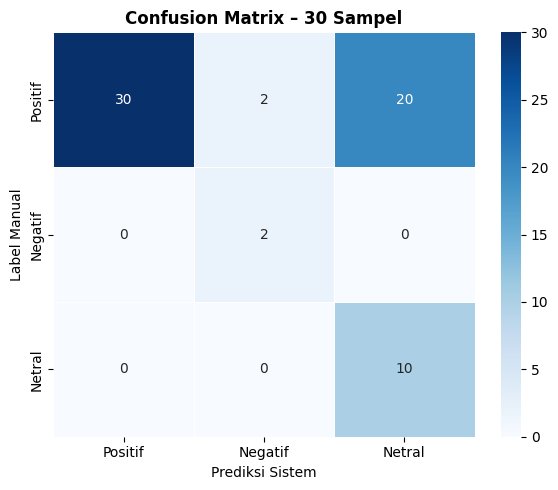

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_manual, y_pred, labels=classes)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, linewidths=0.5, ax=ax)
ax.set_xlabel('Prediksi Sistem'); ax.set_ylabel('Label Manual')
ax.set_title('Confusion Matrix – 30 Sampel', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Hasil dan Analisis

In [30]:
# Sentimen per aspek
asp_sent = (df_kal_exp.groupby(['aspek','sentimen']).size().unstack(fill_value=0)
            .reindex(columns=['Positif','Negatif','Netral'], fill_value=0))
asp_sent['Total'] = asp_sent.sum(axis=1)
asp_sent['% Pos'] = (asp_sent['Positif'] / asp_sent['Total'] * 100).round(1)
asp_sent['% Neg'] = (asp_sent['Negatif'] / asp_sent['Total'] * 100).round(1)
print('=== SENTIMEN PER ASPEK ===')
print(asp_sent.to_string())

=== SENTIMEN PER ASPEK ===
sentimen  Positif  Negatif  Netral  Total  % Pos  % Neg
aspek                                                  
Karier        169        1      38    208   81.2    0.5
Materi        176        1      46    223   78.9    0.4
Mentor        170        0      26    196   86.7    0.0
Program       279        1      71    351   79.5    0.3
Project       118        2      51    171   69.0    1.2
Skill         105        0      37    142   73.9    0.0
Umum          152        1      71    224   67.9    0.4


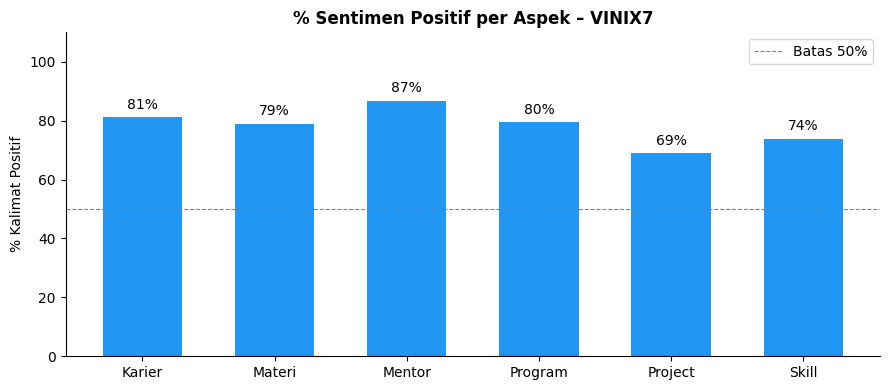

In [31]:
# Bar chart % positif per aspek
asp_f  = asp_sent.drop('Umum', errors='ignore')
colors = ['#2196F3' if v >= 60 else '#FF9800' if v >= 50 else '#F44336'
          for v in asp_f['% Pos']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(asp_f.index, asp_f['% Pos'], color=colors, width=0.6)
ax.axhline(50, color='gray', ls='--', lw=0.8, label='Batas 50%')
ax.bar_label(bars, fmt='%.0f%%', padding=4, fontsize=10)
ax.set_ylim(0, 110)
ax.set_ylabel('% Kalimat Positif')
ax.set_title('% Sentimen Positif per Aspek – VINIX7', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('sentimen_per_aspek.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# % Positif per aspek per divisi
divisi_utama = [d for d in df['divisi'].value_counts().index
                if d not in ('Tidak Disebutkan','Lainnya')][:6]

hasil_divisi = {}
for div in divisi_utama:
    sub = df_kal_exp[df_kal_exp['divisi'] == div]
    row = {}
    for asp in ASPECTS:
        s     = sub[sub['aspek'] == asp]
        total = len(s)
        pos   = (s['sentimen'] == 'Positif').sum()
        row[asp] = round(pos/total*100) if total > 0 else 0
    hasil_divisi[div] = row

df_div = pd.DataFrame(hasil_divisi).T
print('=== % POSITIF PER ASPEK PER DIVISI ===')
print(df_div.to_string())

=== % POSITIF PER ASPEK PER DIVISI ===
                     Mentor  Materi  Project  Skill  Karier  Program
Data Science & ML        90      76       77     86      84       86
Financial & Banking     100      92       83     82     100       83
Web Dev & UI/UX          83      71       81     75      78       75
Brand & Marketing        71      92       64     57      64       86
Human Resources         100      71       67    100      83       77
Bisnis & Manajemen       83      75       57     83     100       80


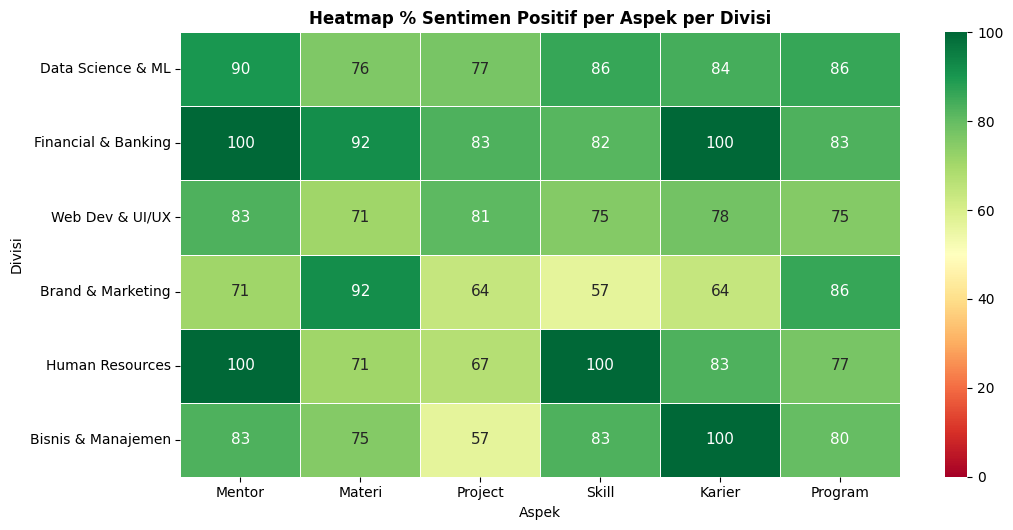

In [33]:
# Heatmap
fig, ax = plt.subplots(figsize=(11, max(4, len(divisi_utama)*0.9)))
sns.heatmap(df_div.astype(int), annot=True, fmt='d', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=0.5, annot_kws={'size':11}, ax=ax)
ax.set_title('Heatmap % Sentimen Positif per Aspek per Divisi', fontweight='bold')
ax.set_xlabel('Aspek'); ax.set_ylabel('Divisi')
plt.tight_layout()
plt.savefig('heatmap_divisi.png', dpi=150, bbox_inches='tight')
plt.show()

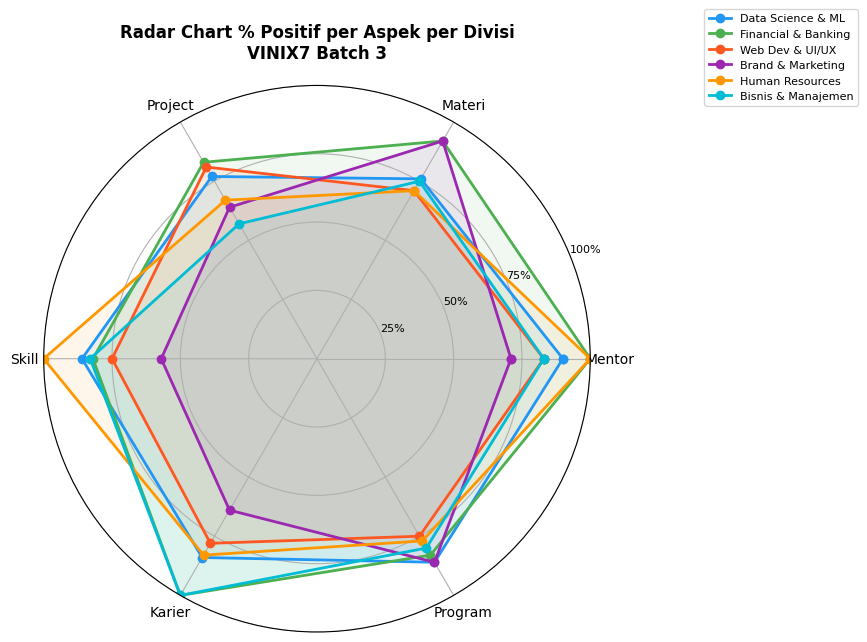

In [34]:
# Radar chart
aspek_label = list(ASPECTS.keys())
N      = len(aspek_label)
angles = [n/float(N)*2*3.14159 for n in range(N)] + [0]
colors_r = ['#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800','#00BCD4']

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))
for idx, (div, row) in enumerate(df_div.iterrows()):
    vals = [row[a] for a in aspek_label] + [row[aspek_label[0]]]
    ax.plot(angles, vals, 'o-', lw=2, color=colors_r[idx%len(colors_r)], label=div)
    ax.fill(angles, vals, alpha=0.08, color=colors_r[idx%len(colors_r)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(aspek_label, fontsize=10)
ax.set_ylim(0, 100); ax.set_yticks([25,50,75,100])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=8)
ax.set_title('Radar Chart % Positif per Aspek per Divisi\nVINIX7 Batch 3', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15), fontsize=8)
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

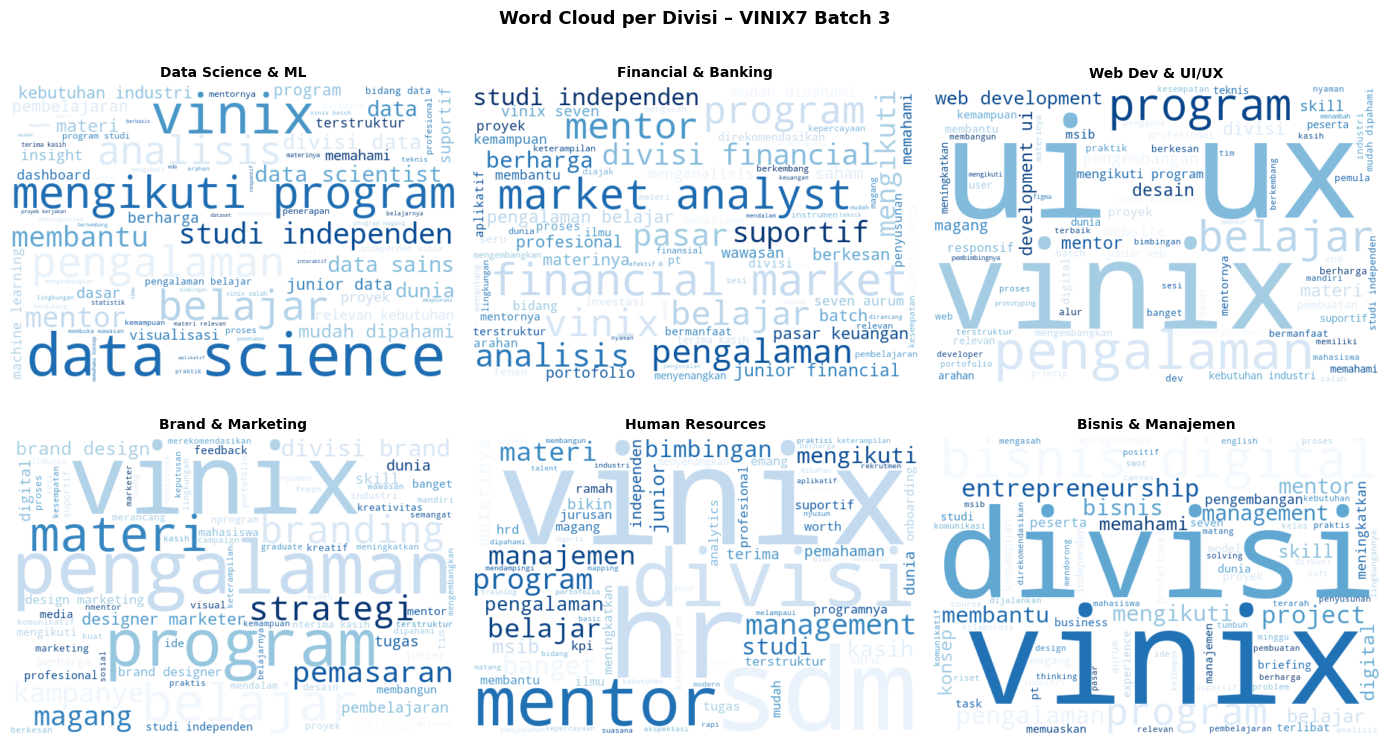

In [35]:
# Word cloud per divisi
ncols = 3
nrows = (len(divisi_utama)+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows*4))
axes = axes.flatten()

for idx, div in enumerate(divisi_utama):
    teks = ' '.join(df[df['divisi']==div]['teks_bersih'])
    wc   = WordCloud(width=600, height=400, background_color='white',
                     max_words=80, colormap='Blues').generate(teks)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off'); axes[idx].set_title(div, fontsize=10, fontweight='bold')

for j in range(idx+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Word Cloud per Divisi – VINIX7 Batch 3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_divisi.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
perbaikan = {
    "tidak keberatan membantu": "Positif",
    "tidak hanya menarik tetapi juga fungsional": "Positif",
}
for substr, label_baru in perbaikan.items():
    mask = df_kal['kalimat'].str.contains(substr, na=False)
    df_kal.loc[mask, 'sentimen'] = label_baru
    df_kal_exp.loc[df_kal_exp['kalimat'].str.contains(substr, na=False), 'sentimen'] = label_baru
    print(f"Diperbaiki: {mask.sum()} kalimat mengandung '{substr[:40]}...' → {label_baru}")

Diperbaiki: 1 kalimat mengandung 'tidak keberatan membantu...' → Positif
Diperbaiki: 1 kalimat mengandung 'tidak hanya menarik tetapi juga fungsion...' → Positif


In [39]:
# Temuan kritis: kalimat negatif terkuat
print('=== KALIMAT NEGATIF TERKUAT ===')
for _, row in df_kal[df_kal['sentimen']=='Negatif'].sort_values('skor').head(10).iterrows():
    print(f'[{row["divisi"]}] skor={row["skor"]:+.1f}')
    print(f'  {str(row["kalimat"])[:150]}')
    print()

=== KALIMAT NEGATIF TERKUAT ===
[Tidak Disebutkan] skor=-4.0
  Selain itu praktiknya juga oke, kurangnya adalah sesi belajarnya yang kurang dan materinya yang terlalu dasar

[Tidak Disebutkan] skor=-2.0
  \n\nNamun, ada satu aspek yang menurut saya perlu ditingkatkan: konsistensi komunikasi dan koordinasi dari pihak penanggung jawab



## 10. Ringkasan Temuan

In [40]:
print('='*65)
print('RINGKASAN TEMUAN – ABSA ULASAN VINIX7 BATCH 3')
print('='*65)

asp_c = asp_sent.drop('Umum', errors='ignore')
print(f'Total ulasan      : {len(df)}')
print(f'Total kalimat     : {len(df_kal)}')
print(f'Aspek terpositif  : {asp_c["% Pos"].idxmax()} ({asp_c["% Pos"].max():.0f}%)')
print(f'Aspek perlu kerja : {asp_c["% Pos"].idxmin()} ({asp_c["% Pos"].min():.0f}%)')
print()
print('Per divisi:')
for div in divisi_utama:
    r = df_div.loc[div]
    print(f'  {div:30s} Terkuat: {r.idxmax()} ({r.max():.0f}%) | '          f'Perlu perhatian: {r.idxmin()} ({r.min():.0f}%)')
print()
print(f'Akurasi evaluasi manual : {acc:.0%} (30 sampel)')
print(f'F1-Score (macro)        : {f1:.0%}')
print()
print('Catatan: Domain lexicon digunakan menggantikan InSet karena')
print('analisis frekuensi menunjukkan 30+ kata umum di InSet salah')
print('diklasifikasikan negatif dalam konteks ulasan program pelatihan.')
print('='*65)

RINGKASAN TEMUAN – ABSA ULASAN VINIX7 BATCH 3
Total ulasan      : 230
Total kalimat     : 984
Aspek terpositif  : Mentor (87%)
Aspek perlu kerja : Project (69%)

Per divisi:
  Data Science & ML              Terkuat: Mentor (90%) | Perlu perhatian: Materi (76%)
  Financial & Banking            Terkuat: Mentor (100%) | Perlu perhatian: Skill (82%)
  Web Dev & UI/UX                Terkuat: Mentor (83%) | Perlu perhatian: Materi (71%)
  Brand & Marketing              Terkuat: Materi (92%) | Perlu perhatian: Skill (57%)
  Human Resources                Terkuat: Mentor (100%) | Perlu perhatian: Project (67%)
  Bisnis & Manajemen             Terkuat: Karier (100%) | Perlu perhatian: Project (57%)

Akurasi evaluasi manual : 66% (30 sampel)
F1-Score (macro)        : 63%

Catatan: Domain lexicon digunakan menggantikan InSet karena
analisis frekuensi menunjukkan 30+ kata umum di InSet salah
diklasifikasikan negatif dalam konteks ulasan program pelatihan.


## 11. Simpan Hasil

In [41]:
df.to_csv('hasil_preprocessing.csv', index=False)
df_kal_exp.to_csv('hasil_absa_kalimat.csv', index=False)
df_div.to_csv('ringkasan_per_divisi.csv')
asp_sent.to_csv('ringkasan_per_aspek.csv')

outputs = ['hasil_preprocessing.csv','hasil_absa_kalimat.csv',
           'ringkasan_per_divisi.csv','ringkasan_per_aspek.csv',
           'top_tfidf.png','confusion_matrix.png',
           'sentimen_per_aspek.png','heatmap_divisi.png',
           'radar_chart.png','wordcloud_divisi.png']

print('Output tersimpan:')
for f in outputs: print(f'  ✓ {f}')
print()
print('Upload semua file + notebook ini ke GitHub!')

Output tersimpan:
  ✓ hasil_preprocessing.csv
  ✓ hasil_absa_kalimat.csv
  ✓ ringkasan_per_divisi.csv
  ✓ ringkasan_per_aspek.csv
  ✓ top_tfidf.png
  ✓ confusion_matrix.png
  ✓ sentimen_per_aspek.png
  ✓ heatmap_divisi.png
  ✓ radar_chart.png
  ✓ wordcloud_divisi.png

Upload semua file + notebook ini ke GitHub!
